In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

state vector dim = 8
n_actions = 4


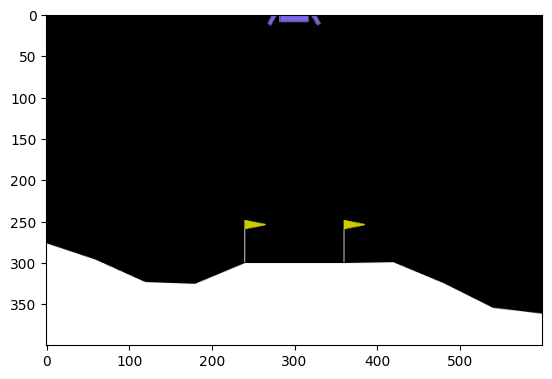

In [2]:
env_id = "LunarLander-v3"
env = gym.make(env_id, render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

env.close()

In [3]:
env

<OrderEnforcing<PassiveEnvChecker<LunarLander<LunarLander-v3>>>>

In [3]:
from IPython import display
from IPython.display import clear_output

In [5]:
def render(env, agent, t_max: int = 1_000):
    s, _ = env.reset()
    clear_output(True)
    plt.imshow(env.render())

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:   
        probs = agent.predict_proba(s.reshape((1,-1))).reshape((n_actions,))

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = np.random.choice(n_actions, p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        plt.imshow(env.render())
        display.display(plt.gcf())
        display.clear_output(wait=True)

        # record sessions like you did before
        s = new_s
        if terminated or truncated:
            break

In [5]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(50, 50, 50, 25),
    activation="relu",
)

agent = agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), classes=list(range(n_actions)))

In [7]:
from copy import deepcopy

In [8]:
env.reset()
env2 = deepcopy(env)
env2.reset()
# env.reset()
print(env.step(0))
print(env2.step(0))

(array([-0.00709982,  1.4015455 , -0.35907656, -0.22116289,  0.00814454,
        0.08049885,  0.        ,  0.        ], dtype=float32), np.float64(-1.1505986071225323), False, False, {})
(array([ 0.00873652,  1.4173362 ,  0.44183263,  0.12972043, -0.01000693,
       -0.09905048,  0.        ,  0.        ], dtype=float32), np.float64(0.05586521075866813), False, False, {})


In [9]:
# render(env, agent, 100)

In [6]:
def generate_session(env_id: str | gym.Env, agent: MLPClassifier, t_max=1000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    if isinstance(env_id, str):
        env = gym.make(env_id)
    else:
        env = env_id
    s, _ = env.reset()

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:   
        probs = agent.predict_proba(s.reshape((1,-1))).reshape((n_actions,))

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = np.random.choice(n_actions, p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward


In [11]:
dummy_states, dummy_actions, dummy_reward = generate_session(env_id, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)


states: [[ 0.00533218  1.4099553   0.5400887  -0.04289166 -0.00617201 -0.12233808
   0.          0.        ]
 [ 0.01066465  1.4084135   0.5393586  -0.06856395 -0.01221726 -0.12091576
   0.          0.        ]
 [ 0.01590404  1.4071507   0.53053975 -0.05618473 -0.01874081 -0.13048334
   0.          0.        ]
 [ 0.02114372  1.4052886   0.53055894 -0.08286623 -0.02526309 -0.13045771
   0.          0.        ]
 [ 0.02624474  1.4037061   0.51744366 -0.0704684  -0.03251928 -0.14513719
   0.          0.        ]]
actions: [0, 2, 0, 2, 3]
reward: -2.983218493435804


In [7]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    # new_rewards = {val[0]: [] for val in states_batch}
    # ids = {val[0]: [] for val in states_batch}
    # for i, states in enumerate(states_batch):
    #     new_rewards[states[0]].append(rewards_batch[i])
    #     ids[states[0]].append(i)
    # mask = [0] * len(rewards_batch)

    # for st in new_rewards:
    #     reward_threshold = np.percentile(new_rewards[st], q=percentile)
    #     for i, r in enumerate(new_rewards[st]):
    #         if r >= reward_threshold:
    #             mask[ids[st][i]] = 1

    reward_threshold = np.percentile(rewards_batch, q=percentile)
    # for i, r in enumerate(rewards_batch):
    #     if r >= reward_threshold:
    #         mask[i] = 1

    elite_states = []
    elite_actions = []

    for i, r in enumerate(rewards_batch):
        if r > reward_threshold:
            elite_states.extend(states_batch[i])
            elite_actions.extend(actions_batch[i])

    return elite_states, elite_actions


In [13]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()
    plt.close()


In [8]:
from joblib import Parallel, delayed

In [9]:
def gen_many_sessions(env_id, agent, t_max, cnt):
    return [generate_session(env_id, agent, t_max) for _ in range(cnt)]

In [20]:
def make_sessions(env_id, agent, n_sessions: int, t_max: int):
    NUM_WORKERS = 50
    results = Parallel(n_jobs=NUM_WORKERS)(
        delayed(gen_many_sessions)(env_id, agent, t_max, n_sessions // NUM_WORKERS)
        for _ in range(NUM_WORKERS)
    )
    ans = []
    for el in results:
        ans.extend(el)
    return ans
    # return results


mean reward = 272.046, threshold=315.297


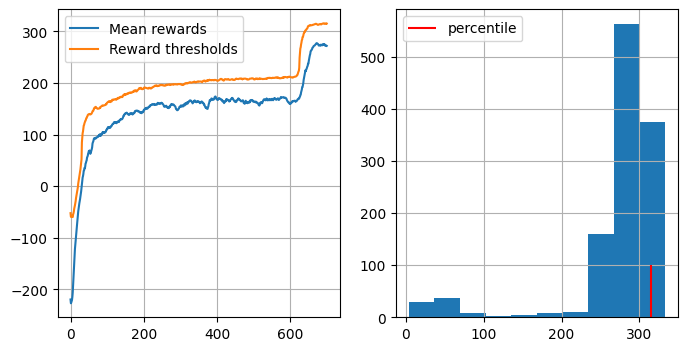

You Win! You may stop training now via KeyboardInterrupt.


In [ ]:
n_sessions = 200
percentile = 90
log = []
buffer = []

for i in range(700):
    # generate new sessions
    sessions = make_sessions(env_id, agent, n_sessions, t_max=500)

    all_ses = []
    all_ses.extend(sessions)
    for el in buffer:
        all_ses.extend(el)

    states_batch, actions_batch, rewards_batch = zip(*all_ses)
    # print(sessions)
    # print(states_batch)
    # print(actions_batch)
    # print(rewards_batch)

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

    # print(elite_actions)
    # print(elite_states)
    agent.partial_fit(elite_states, elite_actions)
    # <YOUR CODE: partial_fit agent to predict elite_actions(y) from elite_states(X)>

    show_progress(
        rewards_batch, log, percentile, reward_range=[np.min(rewards_batch), np.max(rewards_batch)]
    )

    if np.mean(rewards_batch) > 190:
        print("You Win! You may stop training now via KeyboardInterrupt.")
    buffer.append(sessions)
    buffer = buffer[-5:]
    # print(len(buffer))
    # print(len(sessions))
    # print(len(all_ses))
    # input()


In [25]:
from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make(env_id, render_mode="rgb_array"),
    video_folder=f"./{env_id}_videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent, t_max=500) for _ in range(5)]

In [ ]:
def save_agent(agent, path):
    from pickle import dump
    with open(path, 'wb') as f:
        dump(agent, f)

# save_agent(agent, 'lunar_lander_agent.pkl')

In [11]:
def load_agent(path):
    from pickle import load
    with open(path, 'rb') as f:
        return load(f)

In [12]:
model = load_agent('lunar_lander_agent.pkl')

In [22]:
states_batch, actions_batch, rewards_batch = zip(*make_sessions(env, model, 300, 1000))
print(np.mean(rewards_batch))

270.77457582394294
